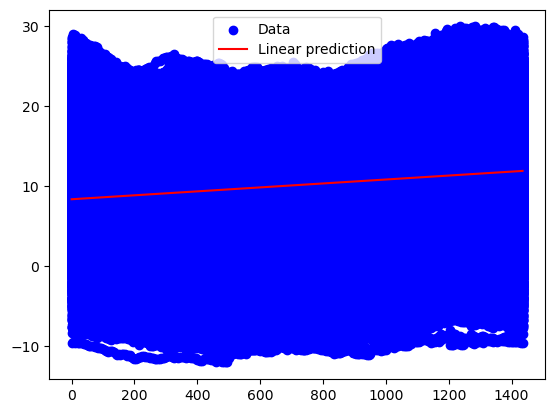

In [2]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

data_dir = 'yosemite-temperatures/yosemite_village'
files = sorted(glob.glob(f"{data_dir}/CRNS0101-05-*-CA_Yosemite_Village_12_W.txt"))
if not files:
    raise FileNotFoundError(f"No Yosemite files found in {data_dir}")
usecols = [1, 2, 8]

data = [np.loadtxt(f, usecols=usecols) for f in files]
data = np.vstack(data)

# Map from HHmm to an integer
data[:, 1] = np.floor_divide(data[:, 1], 100) * 60 + np.mod(data[:, 1], 100)
valid = data[:, 2] > -1000

x_train = data[valid, 1].reshape(-1, 1)
y_train = data[valid, 2]
regr = linear_model.LinearRegression()
regr.fit(x_train, y_train)

x_predict = [[0], [1435]]
y_predict = regr.predict(x_predict)

plt.scatter(data[valid, 1], data[valid, 2], label='Data', color='b')
plt.plot(x_predict, y_predict, label='Linear prediction', color='r')
plt.legend(loc='best')
plt.show()

R²: 0.038449159973870106


/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


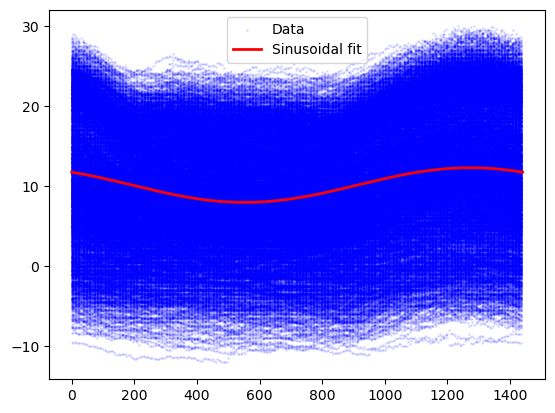

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Transform time into sine/cosine features to capture daily cycle
minutes = data[valid, 1]
period = 1440  # minutes in a day

X = np.column_stack([
    np.sin(2 * np.pi * minutes / period),
    np.cos(2 * np.pi * minutes / period),
])
y = data[valid, 2]

regr = LinearRegression()
regr.fit(X, y)
y_pred = regr.predict(X)

print("R²:", r2_score(y, y_pred))

# Plot
x_plot = np.linspace(0, 1440, 500)
X_plot = np.column_stack([
    np.sin(2 * np.pi * x_plot / period),
    np.cos(2 * np.pi * x_plot / period),
])
plt.scatter(minutes, y, label='Data', color='b', alpha=0.1, s=1)
plt.plot(x_plot, regr.predict(X_plot), label='Sinusoidal fit', color='r', linewidth=2)
plt.legend()
plt.show()

In [4]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

# Build features: raw time + date components
dates = data[valid, 0].astype(int)
day_of_year = np.array([
    (np.datetime64('%d-%02d-%02d' % (d//10000, (d//100)%100, d%100)) -
     np.datetime64('%d-01-01' % (d//10000))).astype(int)
    for d in dates
])
minutes = data[valid, 1]

X = np.column_stack([
    minutes,
    day_of_year,
    np.sin(2 * np.pi * minutes / 1440),
    np.cos(2 * np.pi * minutes / 1440),
    np.sin(2 * np.pi * day_of_year / 365),
    np.cos(2 * np.pi * day_of_year / 365),
])

models = {
    "Linear Regression":     LinearRegression(),
    "Ridge":                 Ridge(alpha=1.0),
    "Random Forest":         RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting":     GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost":               XGBRegressor(n_estimators=100, random_state=42),
}

for name, model in models.items():
    model.fit(X, y)
    print(f"{name:25s} R² = {r2_score(y, model.predict(X)):.4f}")

Linear Regression         R² = 0.6003
Ridge                     R² = 0.6003
Random Forest             R² = 0.6696
Gradient Boosting         R² = 0.6481
XGBoost                   R² = 0.6687


In [8]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone

# Proper evaluation without changing cell 3:
# 1) Chronological holdout split (first 80% train, last 20% test)
# 2) TimeSeriesSplit cross-validation
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

eval_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
}

try:
    eval_models["XGBoost"] = XGBRegressor(n_estimators=200, random_state=42)
except Exception:
    pass

tscv = TimeSeriesSplit(n_splits=5)

print("Chronological holdout + TimeSeriesSplit CV")
for name, model in eval_models.items():
    m = clone(model)
    m.fit(X_train, y_train)
    holdout_r2 = r2_score(y_test, m.predict(X_test))

    cv_scores = []
    for tr_idx, va_idx in tscv.split(X):
        mv = clone(model)
        mv.fit(X[tr_idx], y[tr_idx])
        cv_scores.append(r2_score(y[va_idx], mv.predict(X[va_idx])))

    print(f"{name:25s} holdout R² = {holdout_r2:.4f} | TSCV mean R² = {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")


Chronological holdout + TimeSeriesSplit CV
Linear Regression         holdout R² = 0.5982 | TSCV mean R² = 0.5775 (+/- 0.0502)
Ridge                     holdout R² = 0.5982 | TSCV mean R² = 0.5775 (+/- 0.0502)
Random Forest             holdout R² = 0.5386 | TSCV mean R² = 0.4155 (+/- 0.1108)
Gradient Boosting         holdout R² = 0.5703 | TSCV mean R² = 0.4844 (+/- 0.0737)
XGBoost                   holdout R² = 0.5410 | TSCV mean R² = 0.4202 (+/- 0.1093)


In [7]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# Dedicated XGBoost cell (uses the same X/y and chronological split from above)
try:
    xgb_base = XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        tree_method='hist'
    )

    param_dist = {
        'n_estimators': [200, 300, 500, 700],
        'max_depth': [3, 4, 5, 6, 8],
        'learning_rate': [0.01, 0.03, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'min_child_weight': [1, 3, 5, 7],
        'reg_alpha': [0.0, 0.1, 0.5, 1.0],
        'reg_lambda': [1.0, 2.0, 5.0, 10.0],
    }

    tscv_xgb = TimeSeriesSplit(n_splits=5)
    xgb_search = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=param_dist,
        n_iter=25,
        scoring='r2',
        cv=tscv_xgb,
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )

    xgb_search.fit(X_train, y_train)
    best_xgb = xgb_search.best_estimator_
    xgb_holdout_r2 = r2_score(y_test, best_xgb.predict(X_test))

    print('Best XGBoost params:', xgb_search.best_params_)
    print(f"Best XGBoost CV R²: {xgb_search.best_score_:.4f}")
    print(f"Best XGBoost holdout R²: {xgb_holdout_r2:.4f}")
except NameError:
    print('XGBRegressor not available. Install xgboost and rerun this cell.')


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best XGBoost params: {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best XGBoost CV R²: 0.4370
Best XGBoost holdout R²: 0.5563
